In [1]:
# Run this in a Jupyter cell (with ! prefix) or in your Ubuntu terminal
!pip install torch torchvision opencv-python matplotlib requests transformers
!pip install git+https://github.com/facebookresearch/segment-anything.git

# Download the SAM ViT-B model weights (lighter and faster for exploration)
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-uqezwobp
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-uqezwobp
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Loading DINOv2...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Loading SAM...
Both models are ready.
DINOv2 found the most salient point at (X:25, Y:37)


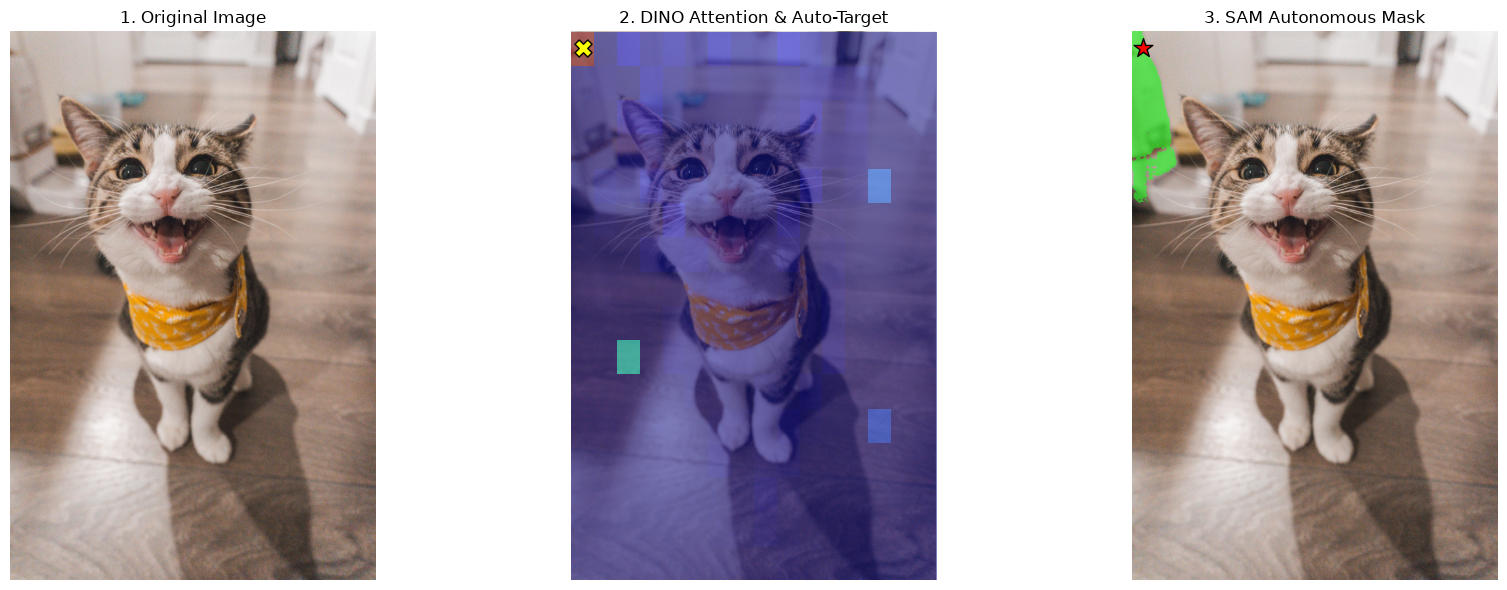

Full pipeline visualization saved to: output_images/03_autonomous_pipeline.png


In [3]:
# [Cell 1: Imports & Setup]
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from segment_anything import sam_model_registry, SamPredictor

os.makedirs("output_images", exist_ok=True)
image_path = "input_images/sample_cat.jpg"
device = "cuda" if torch.cuda.is_available() else "cpu"

# [Cell 2: Load Both Models]
print("Loading DINOv2...")
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dino_model = AutoModel.from_pretrained("facebook/dinov2-base", attn_implementation="eager")
dino_model.eval()

print("Loading SAM...")
sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to(device=device)
predictor = SamPredictor(sam)
print("Both models are ready.")

# [Cell 3: Step 1 - Get Attention Point from DINO]
pil_image = Image.open(image_path).convert("RGB")
inputs = processor(images=pil_image, return_tensors="pt")

with torch.no_grad():
    outputs = dino_model(**inputs, output_attentions=True)

attentions = outputs.attentions[-1]
cls_attention = attentions[0, :, 0, 1:].mean(dim=0)

patch_h = inputs["pixel_values"].shape[2] // 14
patch_w = inputs["pixel_values"].shape[3] // 14
attention_map = cls_attention.reshape(patch_h, patch_w).numpy()

# Find the patch with the highest attention score
max_idx = np.unravel_index(np.argmax(attention_map), attention_map.shape)

# Convert patch index back to original image pixel coordinates
# Each patch is 14x14 pixels. We take the center of the winning patch.
# Also adjust for any resizing done by the processor
orig_w, orig_h = pil_image.size
scale_y = orig_h / inputs["pixel_values"].shape[2]
scale_x = orig_w / inputs["pixel_values"].shape[3]

target_y = int((max_idx[0] * 14 + 7) * scale_y)
target_x = int((max_idx[1] * 14 + 7) * scale_x)

auto_point = np.array([[target_x, target_y]])
print(f"DINOv2 found the most salient point at (X:{target_x}, Y:{target_y})")

# [Cell 4: Step 2 - Pass Point to SAM]
cv_image = cv2.imread(image_path)
cv_image_rgb = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)

predictor.set_image(cv_image_rgb)
masks, scores, _ = predictor.predict(
    point_coords=auto_point,
    point_labels=np.array([1]), # Foreground
    multimask_output=True
)
best_mask = masks[np.argmax(scores)]

# [Cell 5: Visualize the Autonomous Pipeline]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original
axes[0].imshow(cv_image_rgb)
axes[0].set_title("1. Original Image")
axes[0].axis("off")

# 2. DINO Attention
axes[1].imshow(cv_image_rgb)
axes[1].imshow(attention_map, cmap="jet", alpha=0.5, extent=(0, orig_w, orig_h, 0))
axes[1].scatter(target_x, target_y, color="yellow", marker="X", s=150, edgecolors="black")
axes[1].set_title("2. DINO Attention & Auto-Target")
axes[1].axis("off")

# 3. SAM Output
axes[2].imshow(cv_image_rgb)
# Reusing the show_mask logic inline
color = np.array([30/255, 255/255, 30/255, 0.6]) # Green mask
h, w = best_mask.shape[-2:]
mask_overlay = best_mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
axes[2].imshow(mask_overlay)
axes[2].scatter(target_x, target_y, color="red", marker="*", s=200, edgecolors="black")
axes[2].set_title("3. SAM Autonomous Mask")
axes[2].axis("off")

plt.tight_layout()
output_path = "output_images/03_autonomous_pipeline.png"
plt.savefig(output_path, bbox_inches="tight", dpi=150)
plt.show()

print(f"Full pipeline visualization saved to: {output_path}")

In [ ]:
# 1. Gerekli kütüphaneleri requirements.txt dosyasına yazdırın
pip freeze > requirements.txt

# 2. Jupyter container'ında kimlik bilginiz yoksa git hata verir. 
# Kendi isminizi ve mailinizi yazarak bu ayarı yapın:
git config --global user.name "mistova"
git config --global user.email "windowslive2798@gmail.com"

# 3. Git repository'sini başlatın
git init

# 4. Gereksiz Jupyter önbellek dosyalarını GitHub'a göndermemek için .gitignore oluşturun
echo ".ipynb_checkpoints/" > .gitignore

# 5. Tüm dosyaları listeye ekleyin
git add .gitignore
git add *.ipynb requirements.txt input_images/ output_images/ README.md

# 6. İlk commit'i (kayıt noktasını) oluşturun
git commit -m "Initial commit: DINO & SAM integration baseline with exploration notebooks"

# 7. Ana dalın (branch) adını 'main' olarak ayarlayın
git branch -M main

# 8. GitHub'daki deponuzu buraya bağlayın 
# (github.com'da depoyu DINO-SAM-Experiment adıyla oluşturduğunuzu varsayıyorum)
git remote add origin https://github.com/mistova/DINO-SAM-Experiment.git

# 9. Kodları GitHub'a gönderin
git push -u origin main